# Customer-Level Analytics

Who are our customers and how do they behave?

In [8]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_parquet('data/cleaned_data.parquet', engine='pyarrow')
df['InvoiceMonth'] = df['InvoiceDateTime'].dt.to_period('M')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1027838 entries, 0 to 1027837
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Invoice           1027838 non-null  str           
 1   StockCode         1027838 non-null  str           
 2   Description       1027838 non-null  str           
 3   Quantity          1027838 non-null  int64         
 4   InvoiceDate       1027838 non-null  object        
 5   Price             1027838 non-null  float64       
 6   CustomerID        1027838 non-null  str           
 7   Country           1027838 non-null  str           
 8   InvoiceDateTime   1027838 non-null  datetime64[us]
 9   InvoiceTime       1027838 non-null  object        
 10  InvoiceHour       1027838 non-null  int32         
 11  InvoiceDayOfWeek  1027838 non-null  str           
 12  is_guest          1027838 non-null  bool          
 13  is_cancellation   1027838 non-null  bool          
 1

In [11]:
customer_df = df[
    (~df['is_cancellation']) &
    (~df['is_non_product']) &
    (~df['is_guest'])
].copy()

In [12]:
customer_df['CustomerID'].nunique()

5853

## Customer Segmentation

We will calculate the following columns to be used for customer segmentation. 
- Recency
- Frequency
- Monetary
- Tenure (days since first purchase)
- Average order value
- Unique products purchased (proxy for diversity/breadth)

### RFM Analysis

RFM stands for Recency, Frequency, and Monetary Value. It is a marketing model used to analyze and group customers based on their past buying behavior. Businesses use it to find their best or most loyal buyers.  

The Three Core Metrics:  
**Recency (R):** How long ago the customer made their last purchase. Fresh buyers get a high score because they remember the brand.  
**Frequency (F):** How often the customer buys things in a set time. Higher numbers mean more loyal shoppers.  
**Monetary Value (M):** How much money the customer spends overall. Bigger spenders get a high score.  

Recency:
- It is calculated by subtracting each customer's most recent InvoiceDate from a fixed reference date.
- In our case, we will use this reference date as one day after the last date (9th Dec 2011) in the dataset, which is 10/12/2022.

In [13]:
from datetime import timedelta, date

recency_df = customer_df.groupby(['CustomerID'], as_index=False)['InvoiceDate'].max()
recency_df.columns = ['CustomerID', 'LastPurchaseDate']
recent_date = recency_df['LastPurchaseDate'].max() + timedelta(days=1)
recency_df['Recency'] = recency_df['LastPurchaseDate'].apply(lambda x: (recent_date - x).days)
recency_df.head()

,CustomerID,LastPurchaseDate,Recency
0,12346,2011-01-18,326
1,12347,2011-12-07,3
2,12348,2011-09-25,76
3,12349,2011-11-21,19
4,12350,2011-02-02,311


In [14]:
# Frequency - Total number of times a customer has purchased in the given window 
frequency_df = customer_df.groupby(['CustomerID'], as_index=False)['Invoice'].nunique()
frequency_df.columns = ['CustomerID', 'Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346,3
1,12347,8
2,12348,5
3,12349,3
4,12350,1


In [15]:
# Monetary - Total amount spent by a customer in the given window
monetary_df = customer_df.groupby(['CustomerID'], as_index=False)['Revenue'].sum()
monetary_df.columns = ['CustomerID', 'Monetary']
monetary_df.head()

,CustomerID,Monetary
0,12346,77352.96
1,12347,4921.53
2,12348,1658.40
3,12349,3678.69
4,12350,294.40


In [16]:
# Merge all three
rf_df = recency_df.merge(frequency_df, on='CustomerID')
rfm_df = rf_df.merge(monetary_df, on='CustomerID').drop(['LastPurchaseDate'], axis=1)
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,3,77352.96
1,12347,3,8,4921.53
2,12348,76,5,1658.40
3,12349,19,3,3678.69
4,12350,311,1,294.40


In [17]:
rfm_df.describe()

,Recency,Frequency,Monetary
count,5853.000000,5853.000000,5853.000000
mean,200.700666,6.252691,2916.210958
std,208.519603,12.750278,14305.694223
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,339.500000
50%,96.000000,3.000000,856.010000
75%,380.000000,7.000000,2240.900000
max,739.000000,373.000000,580987.040000


- It can be seen that the values vary drastically. The range is large and there are a few outliers. Hence we will go for rank normalization.
- Percentile rank normalization inherently compresses extreme values.
- A customer with £700K Monetary and one with £77K both just land near the 99th-100th percentile — the raw magnitude gap between them (which would badly distort a K-means fit using untransformed £ values) disappears once you're working in rank-space.
- This is functionally similar to what a log-transform does for skew, but even more robust, since it's bounded to a fixed 0-100 range no matter how extreme the tail is.

In [18]:
# Find the rank for all three
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

In [19]:
# Normalize the ranks
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

In [20]:
rfm_df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465
1,12347,3,8,4921.53,97.172721,79.446438,89.185033
2,12348,76,5,1658.40,54.180946,66.461644,67.862635
3,12349,19,3,3678.69,80.954421,49.444729,84.606185
4,12350,311,1,294.40,29.943454,13.839057,20.707330


### Tenure

It can be defined as the total period a customer has been purchasing at the company.  
We will calculate it as the time period between the first purchase in our dataset to the last date of the dataset.

In [21]:
tenure_df = customer_df.groupby(['CustomerID'], as_index=False)['InvoiceDate'].min()
tenure_df.columns = ['CustomerID', 'FirstPurchaseDate']
recent_date = customer_df['InvoiceDate'].max() + timedelta(days=1)
tenure_df['Tenure'] = tenure_df['FirstPurchaseDate'].apply(lambda x: (recent_date-x).days)
tenure_df['Tenure_rank'] = tenure_df['Tenure'].rank(ascending=False)
tenure_df['Tenure_rank_norm'] = (tenure_df['Tenure_rank'] / tenure_df['Tenure_rank'].max()) * 100
tenure_df.drop(['FirstPurchaseDate', 'Tenure_rank'], axis=1, inplace=True)
segmentation_df = rfm_df.merge(tenure_df, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581


### Average Order Value

AOV is the average amount of money a customer spends ot a time.

In [22]:
order_revenue = customer_df.groupby(['CustomerID', 'Invoice'], as_index=False)['Revenue'].sum()
avg_df = order_revenue.groupby('CustomerID', as_index=False)['Revenue'].mean()
avg_df.columns = ['CustomerID', 'AvgOrderValue']
avg_df['AOV_rank'] = avg_df['AvgOrderValue'].rank(ascending=False)
avg_df['AOV_rank_norm'] = (avg_df['AOV_rank'] / avg_df['AOV_rank'].max()) * 100
segmentation_df = segmentation_df.merge(avg_df, on='CustomerID').drop('AOV_rank', axis=1)
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,0.034171
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,10.353665
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,37.792585
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,2.084401
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,46.676918


### Unique Products Purchased

We will also calculate the total number of unique products purchased by customers throughout the dataset.  
This helps us understand the product diversity in our dataset.

In [23]:
unique_df = customer_df.groupby(['CustomerID'], as_index=False)['StockCode'].nunique()
unique_df.columns = ['CustomerID', 'Diversity']
unique_df['Diversity_rank'] = unique_df['Diversity'].rank(ascending=False)
unique_df['Diversity_rank_norm'] = (unique_df['Diversity_rank'] / unique_df['Diversity_rank'].max()) * 100
segmentation_df = segmentation_df.merge(unique_df, on='CustomerID').drop('Diversity_rank', axis=1)
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,0.034171,25,68.398792
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,10.353665,126,19.697885
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,37.792585,24,69.572723
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,2.084401,137,17.781614
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,46.676918,16,79.671990


### Clustering

RFM/behavioral features are continuous and roughly convex-shaped after rank-normalization. Hence, we can use the K-Means algorithm for clustering as it is fast and efficient for large datasets as well. 

In [24]:
segmentation_df.dtypes

CustomerID                 str
Recency                  int64
Frequency                int64
Monetary               float64
R_rank_norm            float64
F_rank_norm            float64
M_rank_norm            float64
Tenure                   int64
Tenure_rank_norm       float64
AvgOrderValue          float64
AOV_rank_norm          float64
Diversity                int64
Diversity_rank_norm    float64
dtype: object

In [25]:
from sklearn.cluster import KMeans

# We will only use the normalized features for clustering
clustering_features = ['R_rank_norm', 'F_rank_norm', 'M_rank_norm','Tenure_rank_norm', 'AOV_rank_norm', 'Diversity_rank_norm']

X = segmentation_df[clustering_features]

scores = []
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, max_iter=40, verbose=False).fit(X)
    scores.append(kmeans.inertia_)

print(len(scores))

5


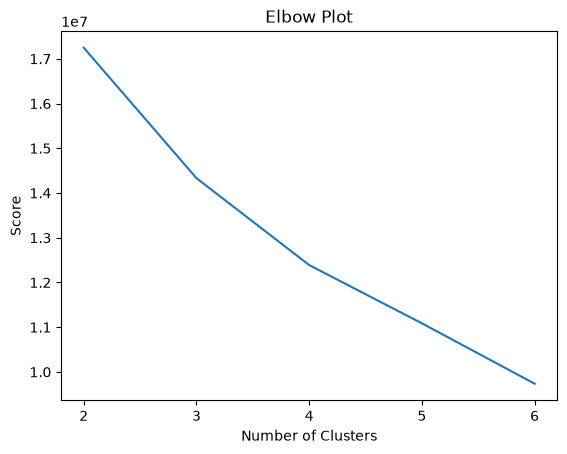

In [26]:
# Plot the elbow curve
import matplotlib.pyplot as plt

plt.plot(range(2, 7, 1), scores)
plt.xticks(ticks=range(2,7))
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("Elbow Plot")
plt.show()

In [27]:
# Calculate the silhoutte scores
from sklearn.metrics import silhouette_score

for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, max_iter=40, verbose=False).fit(X)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"For cluster {i}, the silhoutte score is {silhouette_avg}")

For cluster 2, the silhoutte score is 0.34424987609493946
For cluster 3, the silhoutte score is 0.27202215640745636
For cluster 4, the silhoutte score is 0.25857211459890167
For cluster 5, the silhoutte score is 0.24764618958093365
For cluster 6, the silhoutte score is 0.24393632554292566


- We can see there are two slight inflections or elbows at 3 and 4.
- The silhoutte score is best for 2 clusters. But selecting 2 clusters will not be helpful from a business perspective.
- Selecting either 3 or 4 seems like a better choice. We could try to run the algorithm for both and check the clusters.

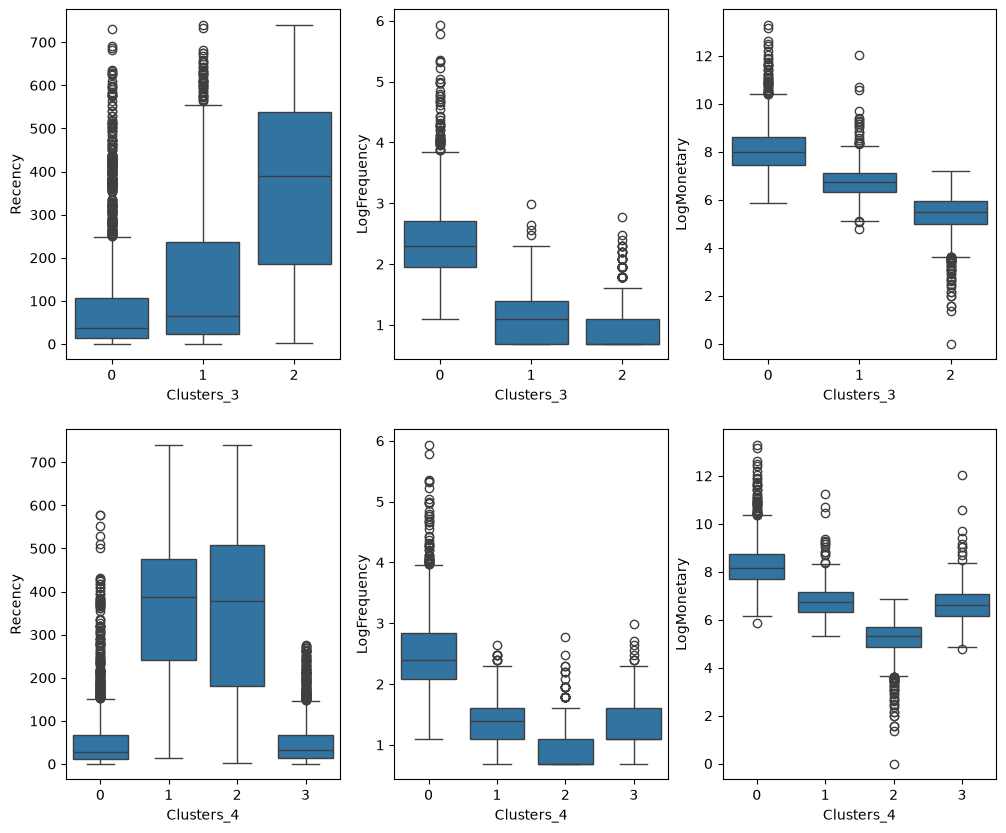

In [28]:
import seaborn as sns

trials = [3, 4]

segmentation_df['LogMonetary'] = np.log1p(segmentation_df['Monetary'])
segmentation_df['LogFrequency'] = np.log1p(segmentation_df['Frequency'])

fig, axes = plt.subplots(2, 3, figsize=(12, 10))

for i, j in enumerate(trials):
    kmeans = KMeans(n_clusters=j, max_iter=40, verbose=False).fit(X)
    clusters = kmeans.labels_
    segmentation_df[f'Clusters_{j}'] = clusters
    sns.boxplot(x=f'Clusters_{j}', y='Recency', data=segmentation_df, ax=axes[i, 0])
    sns.boxplot(x=f'Clusters_{j}', y='LogFrequency', data=segmentation_df, ax=axes[i, 1])
    sns.boxplot(x=f'Clusters_{j}', y='LogMonetary', data=segmentation_df, ax=axes[i, 2])
    
plt.show()

There seems to be a distinct separation between clusters in both cases.  
We can check the mean/median for actual values of our columns - Recency, Monetary, Frequency, etc.

In [29]:
segmentation_df.groupby('Clusters_3')[['Recency','Frequency','Monetary','AvgOrderValue','Tenure','Diversity']].agg(['mean','median','count'])

Recency               Frequency                  Monetary  \
                  mean median count       mean median count         mean   
Clusters_3                                                                 
0            93.385542   36.0  2158  13.255329    9.0  2158  6692.754788   
1           147.116898   66.0  1728   2.609375    2.0  1728  1192.213636   
2           365.509405  390.0  1967   1.770717    1.0  1967   287.479787   

                          AvgOrderValue                        Tenure         \
             median count          mean      median count        mean median   
Clusters_3                                                                     
0           2995.15  2158    446.763562  332.567745  2158  629.498146  670.0   
1            828.68  1728    541.560160  356.304167  1728  305.729167  299.5   
2            242.06  1967    177.709562  158.650000  1967  452.601932  480.0   

                   Diversity               
           count        mean median count  
Clusters_3                                 
0           2158  164.049583  124.0  2158  
1           1728   51.193287   42.0  1728  
2           1967   19.580580   15.0  1967

In [30]:
segmentation_df.groupby('Clusters_4')[['Recency','Frequency','Monetary','AvgOrderValue','Tenure','Diversity']].agg(['mean','median','count'])

Recency               Frequency                  Monetary  \
                  mean median count       mean median count         mean   
Clusters_4                                                                 
0            56.690889   27.0  1789  14.921744   10.0  1789  7701.614484   
1           374.704000  388.5  1250   3.024000    3.0  1250  1196.332602   
2           350.489889  379.0  1533   1.563601    1.0  1533   225.251246   
3            52.771272   32.0  1281   2.907884    2.0  1281  1131.669408   

                          AvgOrderValue                        Tenure         \
             median count          mean      median count        mean median   
Clusters_4                                                                     
0           3550.91  1789    454.839934  352.002222  1789  628.354947  669.0   
1            850.09  1250    475.023179  330.218750  1250  592.843200  618.5   
2            200.63  1533    158.509582  145.920000  1533  416.558382  429.0   
3            757.59  1281    467.606267  308.525000  1281  213.317721  181.0   

                   Diversity               
           count        mean median count  
Clusters_4                                 
0           1789  181.714925  141.0  1789  
1           1250   51.164000   43.5  1250  
2           1533   15.592303   12.0  1533  
3           1281   53.122560   41.0  1281

- We can see that difference between mean and median is much larger in case of 3 clusters. 
- When a cluster's mean is more than double its median, that's a strong sign the cluster is blending two different behavioral groups — some genuinely recent customers and some meaningfully lapsed ones, averaged together into one bucket that doesn't represent either group well.
- Compare that to K=4, where every cluster's mean and median sit much closer together (e.g., Cluster 1: 49.4 vs 25 — still some spread, but nowhere near the K=3 distortion) — a sign of tighter, more internally consistent groups.

Using 4 clusters seems to be a better choice after comparison. We can perform a sanity-check by comparing our findings with Hierarchical Clustering.

col_0,0,1,2,3
row_0,,,,
0,0,1640,145,4
1,339,228,658,25
2,1117,0,364,52
3,116,127,290,748


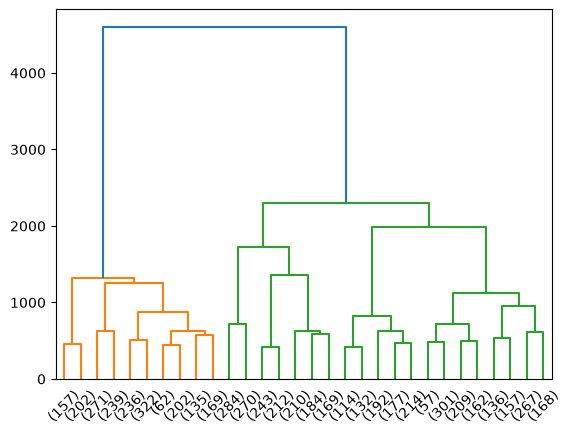

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Quick dendrogram for visual sanity check
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30)

# Compare cluster assignment agreement with K-means
hier = AgglomerativeClustering(n_clusters=4, linkage='ward')
hier_labels = hier.fit_predict(X)

# Cross-tab against your K-means labels to see how much they agree
pd.crosstab(clusters, hier_labels)

- row_0 = your K-means cluster labels (0-3), col_0 = your hierarchical cluster labels (0-3). 
Each cell is "how many customers got K-means label X and hierarchical label Y."
- This is checking agreement, not accuracy — there's no ground truth here, just whether two different methods independently landed on similar groupings.

**Note:** Cluster numbers are arbitrary and don't correspond across methods. K-means cluster "0" has no inherent relationship to hierarchical cluster "0" — they're just labels each algorithm assigned independently. So you read this by looking for each row's dominant column (largest value), not by matching same-numbered labels.

The grouping seems largely consistent in both clustering algorithms.

In [32]:
segmentation_df = segmentation_df.drop(['Clusters_3', 'Clusters_4'], axis=1)

**Final K-Means Clustering**

In [33]:
clustering_features = ['R_rank_norm', 'F_rank_norm', 'M_rank_norm','Tenure_rank_norm', 'AOV_rank_norm', 'Diversity_rank_norm']

X = segmentation_df[clustering_features]

kmeans = KMeans(n_clusters=4, max_iter=40, verbose=False).fit(X)
clusters = kmeans.labels_
segmentation_df['Cluster'] = clusters

In [34]:
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,0.034171,25,68.398792,11.256147,1.386294,2
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,10.353665,126,19.697885,8.501578,2.197225,3
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,37.792585,24,69.572723,7.414211,1.791759,2
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,2.084401,137,17.781614,8.210584,1.386294,3
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,46.676918,16,79.671990,5.688330,0.693147,1


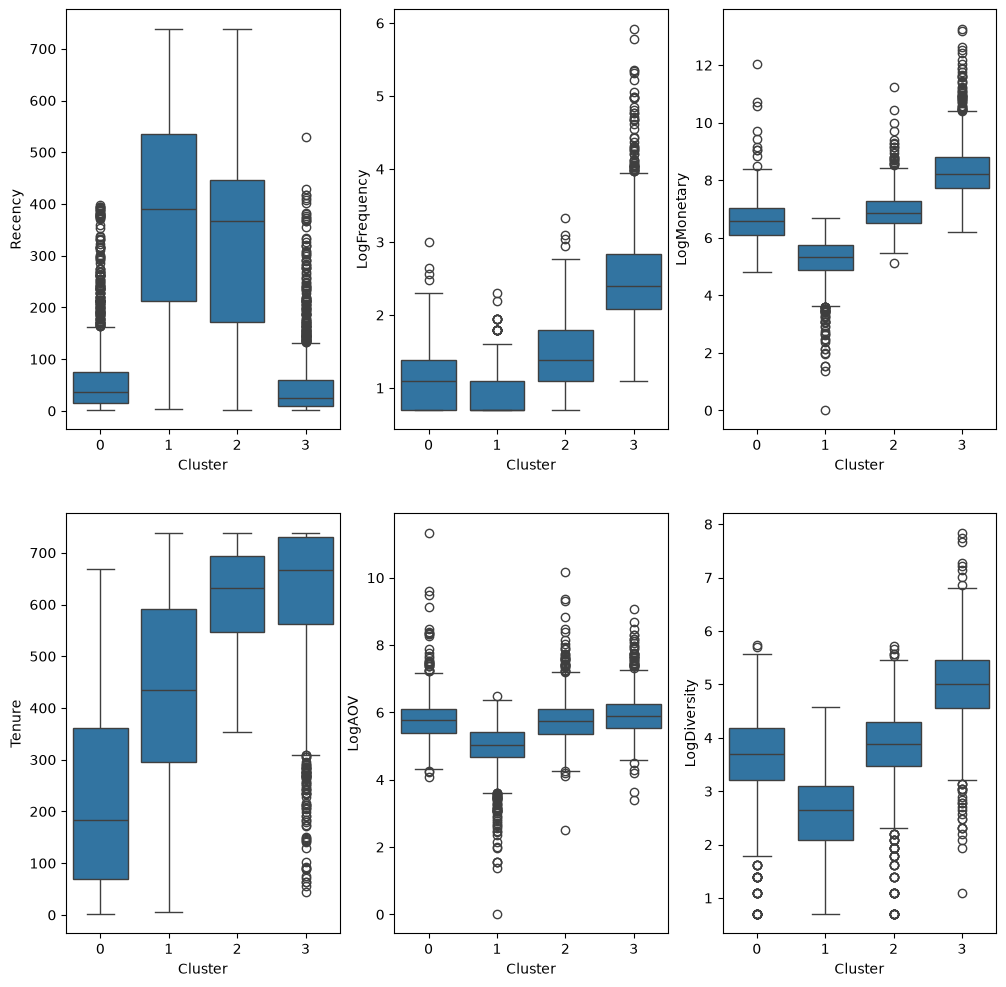

In [35]:
import seaborn as sns

segmentation_df['LogAOV'] = np.log1p(segmentation_df['AvgOrderValue'])
segmentation_df['LogDiversity'] = np.log1p(segmentation_df['Diversity'])

fig, axes = plt.subplots(2, 3, figsize=(12, 12))

sns.boxplot(x='Cluster', y='Recency', data=segmentation_df, ax=axes[0, 0])
sns.boxplot(x='Cluster', y='LogFrequency', data=segmentation_df, ax=axes[0, 1])
sns.boxplot(x='Cluster', y='LogMonetary', data=segmentation_df, ax=axes[0, 2])
sns.boxplot(x='Cluster', y='Tenure', data=segmentation_df, ax=axes[1, 0])
sns.boxplot(x='Cluster', y='LogAOV', data=segmentation_df, ax=axes[1, 1])
sns.boxplot(x='Cluster', y='LogDiversity', data=segmentation_df, ax=axes[1, 2])
    
plt.show()

Analysis:



## Customer Profiling

We will now calculate the below values for further profiling our customer segments:
- Average basket size (units/order)
- Average price paid
- Total units
- Revenue/month
- Percentage of total company revenue
- Average days between purchases
- Number of active months

### Average Basket Size (Units/Order)

In [43]:
# Average number of items a customer buys in a single transaction
order_size = customer_df.groupby(['CustomerID', 'Invoice'], as_index=False)['Quantity'].sum()
avg_size = order_size.groupby(['CustomerID'], as_index=False)['Quantity'].mean()
avg_size.columns = ['CustomerID', 'AvgBasketSize']
segmentation_df = segmentation_df.merge(avg_size, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,0.034171,25,68.398792,11.256147,1.386294,2,10.157561,3.258097,24746.333333
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,10.353665,126,19.697885,8.501578,2.197225,3,6.423557,4.844187,370.875000
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,37.792585,24,69.572723,7.414211,1.791759,2,5.807181,3.218876,540.800000
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,2.084401,137,17.781614,8.210584,1.386294,3,7.112515,4.927254,540.333333
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,46.676918,16,79.671990,5.688330,0.693147,1,5.688330,2.833213,196.000000


### Total Units

In [48]:
# Total number of items bought by a customer
total_units = customer_df.groupby('CustomerID', as_index=False)['Quantity'].sum()
total_units.columns = ['CustomerID', 'TotalUnits']
segmentation_df = segmentation_df.merge(total_units, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,0.034171,25,68.398792,11.256147,1.386294,2,10.157561,3.258097,24746.333333,74239
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,10.353665,126,19.697885,8.501578,2.197225,3,6.423557,4.844187,370.875000,2967
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,37.792585,24,69.572723,7.414211,1.791759,2,5.807181,3.218876,540.800000,2704
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,2.084401,137,17.781614,8.210584,1.386294,3,7.112515,4.927254,540.333333,1621
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,46.676918,16,79.671990,5.688330,0.693147,1,5.688330,2.833213,196.000000,196


### Average Revenue Per Month

In [53]:
avg_rpm = customer_df.groupby(['CustomerID', 'InvoiceMonth'], as_index=False)['Revenue'].sum()
avg_rpm = avg_rpm.groupby('CustomerID', as_index=False)['Revenue'].mean()
avg_rpm.columns = ['CustomerID', 'AvgRevPerMonth']
segmentation_df = segmentation_df.merge(avg_rpm, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits,AvgRevPerMonth
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,...,25,68.398792,11.256147,1.386294,2,10.157561,3.258097,24746.333333,74239,25784.32000
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,...,126,19.697885,8.501578,2.197225,3,6.423557,4.844187,370.875000,2967,615.19125
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,...,24,69.572723,7.414211,1.791759,2,5.807181,3.218876,540.800000,2704,331.68000
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,...,137,17.781614,8.210584,1.386294,3,7.112515,4.927254,540.333333,1621,1226.23000
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,...,16,79.671990,5.688330,0.693147,1,5.688330,2.833213,196.000000,196,294.40000


### Percentage of Total Company Revenue

In [100]:
total_revenue = customer_df['Revenue'].sum()
cust_rev = customer_df.groupby('CustomerID', as_index=False)['Revenue'].sum()
cust_rev['PercentTotalRevenue'] = (cust_rev['Revenue'] / total_revenue) * 100
segmentation_df = segmentation_df.merge(cust_rev, on='CustomerID').drop('Revenue', axis=1)
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits,AvgRevPerMonth,Percent_Total_Revenue,TotalActiveMonths,AvgDaysBetweenPurchases,PercentTotalRevenue
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,...,2,10.157561,3.258097,24746.333333,74239,25784.32000,0.453189,3,13.416667,0.453189
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,...,3,6.423557,4.844187,370.875000,2967,615.19125,0.028834,8,1.819005,0.028834
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,...,2,5.807181,3.218876,540.800000,2704,331.68000,0.009716,5,8.066667,0.009716
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,...,3,7.112515,4.927254,540.333333,1621,1226.23000,0.021552,3,3.339181,0.021552
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,...,1,5.688330,2.833213,196.000000,196,294.40000,0.001725,1,0.000000,0.001725


### Average Days Between Purchases

In [85]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])

avg_days_between_purchases = (
    customer_df
    .sort_values(['CustomerID', 'InvoiceDate'])    # Sort before grouping
    .groupby('CustomerID')['InvoiceDate']
    .apply(lambda x: x.diff().dt.days.mean())      # Diff calculates the difference between the current date and the previous date
    .reset_index(name='AvgDaysBetweenPurchases')
)

avg_days_between_purchases.head()

,CustomerID,AvgDaysBetweenPurchases
0,12346,13.416667
1,12347,1.819005
2,12348,8.066667
3,12349,3.339181
4,12350,0.000000


In [86]:
# The average days between purchases will be NaN for those customers who bought only once
# We will leave it as it is - Filling it with 0 would mean the customer has bought multiple times in the same day
avg_days_between_purchases['AvgDaysBetweenPurchases'].isna().sum()

np.int64(101)

In [87]:
segmentation_df = segmentation_df.merge(avg_days_between_purchases, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits,AvgRevPerMonth,Percent_Total_Revenue,TotalActiveMonths,AvgDaysBetweenPurchases
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,...,1.386294,2,10.157561,3.258097,24746.333333,74239,25784.32000,0.453189,3,13.416667
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,...,2.197225,3,6.423557,4.844187,370.875000,2967,615.19125,0.028834,8,1.819005
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,...,1.791759,2,5.807181,3.218876,540.800000,2704,331.68000,0.009716,5,8.066667
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,...,1.386294,3,7.112515,4.927254,540.333333,1621,1226.23000,0.021552,3,3.339181
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,...,0.693147,1,5.688330,2.833213,196.000000,196,294.40000,0.001725,1,0.000000


### Number of Active Months

In [64]:
active_months = customer_df.groupby(['CustomerID'], as_index=False)['InvoiceMonth'].nunique()
active_months.columns = ['CustomerID', 'TotalActiveMonths']
segmentation_df = segmentation_df.merge(active_months, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits,AvgRevPerMonth,Percent_Total_Revenue,TotalActiveMonths
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,29.378097,25784.32000,...,11.256147,1.386294,2,10.157561,3.258097,24746.333333,74239,25784.32000,0.453189,3
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,66.777721,615.19125,...,8.501578,2.197225,3,6.423557,4.844187,370.875000,2967,615.19125,0.028834,8
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,59.473774,331.68000,...,7.414211,1.791759,2,5.807181,3.218876,540.800000,2704,331.68000,0.009716,5
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,41.226721,1226.23000,...,8.210584,1.386294,3,7.112515,4.927254,540.333333,1621,1226.23000,0.021552,3
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,75.166581,294.40000,...,5.688330,0.693147,1,5.688330,2.833213,196.000000,196,294.40000,0.001725,1


## Analysis

In [88]:
segmentation_df.describe()

,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,...,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits,AvgRevPerMonth,Percent_Total_Revenue,TotalActiveMonths,AvgDaysBetweenPurchases
count,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,...,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5752.000000
mean,200.700666,6.252691,2916.210958,50.154215,50.008543,50.008543,474.461814,50.008543,384.330503,50.008543,...,1.547022,1.564668,5.610348,3.768896,256.858798,1796.256791,489.112156,0.017085,4.357424,5.358016
std,208.519603,12.750278,14305.694223,28.953402,28.465358,28.869979,223.257305,28.869616,1254.623145,28.869979,...,0.807781,1.127150,0.736269,1.207862,1473.633957,8898.014865,1530.026850,0.083813,4.492233,18.875149
min,1.000000,1.000000,0.000000,0.042838,13.839057,0.017085,1.000000,0.768836,0.000000,0.017085,...,0.693147,0.000000,0.000000,0.693147,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,26.000000,1.000000,339.500000,24.948595,13.839057,25.012814,312.000000,25.175124,176.120000,25.012814,...,0.693147,1.000000,5.176827,2.995732,92.000000,189.000000,194.420000,0.001989,1.000000,0.000000
50%,96.000000,3.000000,856.010000,50.042838,49.444729,50.008543,530.000000,49.982915,277.806667,50.008543,...,1.386294,2.000000,5.630519,3.828641,155.000000,485.000000,314.390000,0.005015,3.000000,1.951367
75%,380.000000,7.000000,2240.900000,75.197053,76.106270,75.004271,667.000000,75.012814,410.552500,75.004271,...,2.079442,3.000000,6.019937,4.644391,260.000000,1354.000000,490.642857,0.013129,6.000000,4.939840
max,739.000000,373.000000,580987.040000,100.000000,100.000000,100.000000,739.000000,100.000000,84236.250000,100.000000,...,5.924256,3.000000,11.341393,7.842671,87167.000000,367712.000000,84236.250000,3.403839,25.000000,596.000000


In [106]:
segmentation_df.groupby('Cluster').agg({
    'AvgBasketSize' : ['sum','mean'],
    'TotalUnits': ['sum','mean'],
    'AvgRevPerMonth': ['sum','mean'],
    'PercentTotalRevenue': ['sum','mean'],
    'AvgDaysBetweenPurchases': ['sum','mean'],
    'TotalActiveMonths': ['sum','mean']
})

AvgBasketSize             TotalUnits              AvgRevPerMonth  \
                   sum        mean        sum         mean            sum   
Cluster                                                                     
0        375296.565257  284.531134     859995   652.005307   7.540322e+05   
1        181241.702778  114.060228     236102   148.585274   2.854956e+05   
2        475988.001345  375.977884    1379938  1089.998420   6.413990e+05   
3        470868.277216  280.445668    8037456  4787.049434   1.181847e+06   

                    PercentTotalRevenue           AvgDaysBetweenPurchases  \
               mean                 sum      mean                     sum   
Cluster                                                                     
0        571.669588            8.599132  0.006519             6192.691781   
1        179.669954            2.155030  0.001356            10315.617752   
2        506.634264           10.010909  0.007908             8778.691070   
3        703.899181           79.234929  0.047192             5532.306381   

                  TotalActiveMonths            
             mean               sum      mean  
Cluster                                        
0        4.720039              3062  2.321456  
1        6.881666              2183  1.373820  
2        6.956174              4114  3.249605  
3        3.295001             16145  9.615843